# Sensitivity Sampling (v6)

**Model corrections:** T_SUSTAIN=1/3, LER NEM cross-direction power (υ_P=0.20), E-9a/b dropped

Multi-day noise + persistence sensitivity study.

## 1 — Install dependencies

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyomo', 'highspy'], check=True)
print('Dependencies ready.')

## 2 — Data paths

In [ ]:
import os

BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..'))
LOCAL_DATA = os.path.join(BASE_DIR, 'data', 'data_out', 'combined_2025_with_frequency.csv')

assert os.path.exists(LOCAL_DATA), f'Data file not found: {LOCAL_DATA}'
print(f'Data: {LOCAL_DATA}')

## 3 — Configuration

In [ ]:
import warnings, datetime, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyomo.environ import (
    ConcreteModel, Set, Param, Var, Objective, Constraint,
    NonNegativeReals, Reals, Binary, minimize, value, SolverFactory,
)
from pyomo.opt import TerminationCondition

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi':          120,
    'font.size':           10,
    'legend.framealpha':   0.85,
})

# ── Portfolio parameters ─────────────────────────────────────────────────
N_ECS = 10;  B_MAX_EC = 100.0;  S_MAX_EC = 200.0
ETA_MEAN = 0.95;  ETA_SIGMA = 0.0;  T_SUSTAIN = 1/3;  UPSILON_P = 0.20
P_MIN = 100.0;  SOC_INIT_FRAC = 0.5;  SOLVER = 'appsi_highs'
P_B_CHANCE = 0.6;  SCALE_MU = 1.0;  SCALE_SIGMA = 1.0
RANDOM_SEED = 42

P_BAR_AGG = N_ECS * B_MAX_EC
S_AGG     = N_ECS * S_MAX_EC

# ── Alpha values — SET DIRECTLY ──────────────────────────────────────────
ALPHAS = [0.0, 0.1, 0.25, 0.5, 1.0]

# ── Sampling ─────────────────────────────────────────────────────────────
N_SAMPLE_DAYS = 2       # ← change to 30 for full run
MULTI_SEED    = 999

# ── Output ───────────────────────────────────────────────────────────────
OUT_DIR     = os.path.join(BASE_DIR, 'data', 'data_out')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

ALL_VAR_KEYS = ['load', 'pv', 'spot',
                'fcrd_up_early', 'fcrd_dn_early',
                'fcrd_up_late',  'fcrd_dn_late']

VAR_LABELS = {
    'load': 'Load', 'pv': 'PV generation', 'spot': 'Spot price',
    'fcrd_up_early': 'FCR-D Up early', 'fcrd_dn_early': 'FCR-D Dn early',
    'fcrd_up_late':  'FCR-D Up late',  'fcrd_dn_late':  'FCR-D Dn late',
}

print(f'Portfolio: {P_BAR_AGG:.0f} kW / {S_AGG:.0f} kWh')
print(f'ALPHAS: {ALPHAS}')
print(f'Sampling {N_SAMPLE_DAYS} days  |  seed={MULTI_SEED}')

## 4 — Synthetic EC portfolio

In [ ]:
rng = np.random.default_rng(42)
EC_LIST = []
for i in range(N_ECS):
    base  = 'b' if rng.random() < P_B_CHANCE else 's'
    scale = -1.0
    while scale <= 0:
        scale = float(rng.normal(SCALE_MU, SCALE_SIGMA))
    EC_LIST.append({'id': f'ec{i:02d}', 'base': base, 'scale': scale,
                    'b_max': B_MAX_EC, 's_max': S_MAX_EC, 'eta': ETA_MEAN})
EC_IDS   = [ec['id'] for ec in EC_LIST]
EC_BY_ID = {ec['id']: ec for ec in EC_LIST}
n_b = sum(1 for e in EC_LIST if e['base'] == 'b')
print(f'{N_ECS} ECs: {n_b} b-type, {N_ECS-n_b} s-type')

10 ECs: 4 b-type, 6 s-type


## 5 — Load & preprocess data

In [ ]:
df_raw = pd.read_csv(LOCAL_DATA, parse_dates=['hour_utc'])
df_raw['spot_dkk']        = df_raw['spot_exkl_vat_ore_kwh'] / 100.0
df_raw['buy_price_dkk']   = df_raw['buy_price_inkl_vat_ore_kwh'] / 100.0
df_raw['sell_price_dkk']  = df_raw['sell_price_inkl_vat_ore_kwh'] / 100.0
df_raw['buy_markup_dkk']  = df_raw['buy_price_dkk']  - df_raw['spot_dkk']
df_raw['sell_markup_dkk'] = df_raw['sell_price_dkk'] - df_raw['spot_dkk']
df_raw['fcrd_up_early_dkk'] = df_raw['price_ore_kwh_fcr_d_upp__d_1_early'].fillna(0).clip(lower=0) / 100.0
df_raw['fcrd_up_late_dkk']  = df_raw['price_ore_kwh_fcr_d_upp__d_1_late' ].fillna(0).clip(lower=0) / 100.0
df_raw['fcrd_dn_early_dkk'] = df_raw['price_ore_kwh_fcr_d_ned__d_1_early'].fillna(0).clip(lower=0) / 100.0
df_raw['fcrd_dn_late_dkk']  = df_raw['price_ore_kwh_fcr_d_ned__d_1_late' ].fillna(0).clip(lower=0) / 100.0
df_raw['y_act_up'] = df_raw['y_act_fcrd_up'  ].fillna(0).clip(0, 1)
df_raw['y_act_dn'] = df_raw['y_act_fcrd_down'].fillna(0).clip(0, 1)
df = df_raw[df_raw['data_quality_flag'] == 0].copy()
df['date'] = df['hour_utc'].dt.date
df_b = df[df['ec_id'] == 'b'].set_index('hour_utc').sort_index()
df_s = df[df['ec_id'] == 's'].set_index('hour_utc').sort_index()
all_dates     = sorted(set(df_b.index.date))
all_dates_set = set(all_dates)
print(f'EC b: {len(df_b)} rows  |  EC s: {len(df_s)} rows')
print(f'Date range: {all_dates[0]} → {all_dates[-1]}')

EC b: 8745 rows  |  EC s: 8745 rows
Date range: 2025-01-01 → 2025-12-31


## 6 — Empirical σ̂

In [ ]:
def compute_empirical_sigma(series):
    s = series.copy(); s.index = pd.to_datetime(s.index)
    diff = (s - s.shift(24)).dropna()
    return pd.DataFrame({'diff': diff.values, 'hour': diff.index.hour}).groupby('hour')['diff'].std().mean()

def compute_nrmse(forecast, true, mean_level):
    if mean_level == 0: return np.nan
    return np.sqrt(np.mean((forecast - true) ** 2)) / mean_level

empirical_sigmas = {
    'load_b':        compute_empirical_sigma(df_b['consumption']),
    'load_s':        compute_empirical_sigma(df_s['consumption']),
    'pv_b':          compute_empirical_sigma(df_b['pv_production_kwh']),
    'pv_s':          compute_empirical_sigma(df_s['pv_production_kwh']),
    'spot':          compute_empirical_sigma(df_b['spot_dkk']),
    'fcrd_up_early': compute_empirical_sigma(df_b['fcrd_up_early_dkk']),
    'fcrd_dn_early': compute_empirical_sigma(df_b['fcrd_dn_early_dkk']),
    'fcrd_up_late':  compute_empirical_sigma(df_b['fcrd_up_late_dkk']),
    'fcrd_dn_late':  compute_empirical_sigma(df_b['fcrd_dn_late_dkk']),
}
empirical_sigmas['pv'] = (empirical_sigmas['pv_b'] + empirical_sigmas['pv_s']) / 2.0

print('Empirical sigmas computed.')
print(f'ALPHAS: {ALPHAS}  (set directly — not derived from sigmas)')

Empirical sigmas computed.
ALPHAS: [0.0, 0.1, 0.25, 0.5, 1.0]  (set directly — not derived from sigmas)


## 7 — All functions

In [ ]:
# ── Noise helpers ────────────────────────────────────────────────────────
def generate_random_walk_noise(horizon, sigma, rng):
    if sigma <= 0: return np.zeros(horizon)
    return np.cumsum(rng.normal(0, sigma, horizon))

def add_noise_to_vector(true_vec, horizon, sl_start, sl_end, alpha, sigma_hat, rng, scale=1.0):
    if not alpha or alpha <= 0: return true_vec.copy()
    noise = generate_random_walk_noise(horizon, alpha * sigma_hat, rng)
    return np.maximum(0, true_vec + noise[sl_start:sl_end] * scale)

# ── True day ─────────────────────────────────────────────────────────────
def get_true_day(date):
    day_b = df_b[df_b.index.date == date].reset_index(drop=True)
    day_s = df_s[df_s.index.date == date].reset_index(drop=True)
    if len(day_b) != 24 or len(day_s) != 24: return None
    D_true, PV_true = {}, {}
    for ec in EC_LIST:
        src = day_b if ec['base'] == 'b' else day_s
        D_true[ec['id']]  = src['consumption'].values       * ec['scale']
        PV_true[ec['id']] = src['pv_production_kwh'].values * ec['scale']
    return {
        'D': D_true, 'PV': PV_true,
        'buy_price': day_b['buy_price_dkk'].values, 'sell_price': day_b['sell_price_dkk'].values,
        'spot_dkk': day_b['spot_dkk'].values,
        'buy_markup': day_b['buy_markup_dkk'].values, 'sell_markup': day_b['sell_markup_dkk'].values,
        'fcrd_up_early': day_b['fcrd_up_early_dkk'].values, 'fcrd_dn_early': day_b['fcrd_dn_early_dkk'].values,
        'fcrd_up_late':  day_b['fcrd_up_late_dkk'].values,  'fcrd_dn_late':  day_b['fcrd_dn_late_dkk'].values,
        'y_act_up': day_b['y_act_up'].values, 'y_act_dn': day_b['y_act_dn'].values,
        'date': date,
    }

# ── Forecasts ────────────────────────────────────────────────────────────
def make_early_forecast(true_day, noise_config, rng):
    D_fc, PV_fc = {}, {}
    alpha_load = noise_config.get('load', 0); alpha_pv = noise_config.get('pv', 0)
    for ec in EC_LIST:
        D_fc[ec['id']] = add_noise_to_vector(true_day['D'][ec['id']], 48, 24, 48,
            alpha_load, empirical_sigmas[f'load_{ec["base"]}'], rng, ec['scale'])
    if alpha_pv and alpha_pv > 0:
        pv_noise24 = generate_random_walk_noise(48, alpha_pv * empirical_sigmas['pv'], rng)[24:48]
        for ec in EC_LIST:
            PV_fc[ec['id']] = np.maximum(0, true_day['PV'][ec['id']] + pv_noise24 * ec['scale'])
    else:
        for ec in EC_LIST: PV_fc[ec['id']] = true_day['PV'][ec['id']].copy()
    alpha_spot = noise_config.get('spot', 0)
    if alpha_spot and alpha_spot > 0:
        spot_fc = add_noise_to_vector(true_day['spot_dkk'], 48, 24, 48, alpha_spot, empirical_sigmas['spot'], rng)
        buy_fc = np.maximum(0, spot_fc + true_day['buy_markup']); sell_fc = np.maximum(0, spot_fc + true_day['sell_markup'])
    else:
        buy_fc = true_day['buy_price'].copy(); sell_fc = true_day['sell_price'].copy()
    return {
        'date': true_day['date'], 'D': D_fc, 'PV': PV_fc, 'buy_price': buy_fc, 'sell_price': sell_fc,
        'fcrd_up_price': add_noise_to_vector(true_day['fcrd_up_early'], 48, 24, 48, noise_config.get('fcrd_up_early',0), empirical_sigmas['fcrd_up_early'], rng),
        'fcrd_dn_price': add_noise_to_vector(true_day['fcrd_dn_early'], 48, 24, 48, noise_config.get('fcrd_dn_early',0), empirical_sigmas['fcrd_dn_early'], rng),
        'y_act_up': true_day['y_act_up'], 'y_act_dn': true_day['y_act_dn'],
    }

def make_late_forecast(true_day, noise_config, rng):
    D_fc, PV_fc = {}, {}
    alpha_load = noise_config.get('load', 0); alpha_pv = noise_config.get('pv', 0)
    for ec in EC_LIST:
        D_fc[ec['id']] = add_noise_to_vector(true_day['D'][ec['id']], 30, 6, 30,
            alpha_load, empirical_sigmas[f'load_{ec["base"]}'], rng, ec['scale'])
    if alpha_pv and alpha_pv > 0:
        pv_noise24 = generate_random_walk_noise(30, alpha_pv * empirical_sigmas['pv'], rng)[6:30]
        for ec in EC_LIST:
            PV_fc[ec['id']] = np.maximum(0, true_day['PV'][ec['id']] + pv_noise24 * ec['scale'])
    else:
        for ec in EC_LIST: PV_fc[ec['id']] = true_day['PV'][ec['id']].copy()
    return {
        'date': true_day['date'], 'D': D_fc, 'PV': PV_fc,
        'buy_price': true_day['buy_price'], 'sell_price': true_day['sell_price'],
        'fcrd_up_price_late':  add_noise_to_vector(true_day['fcrd_up_late'], 30, 6, 30, noise_config.get('fcrd_up_late',0), empirical_sigmas['fcrd_up_late'], rng),
        'fcrd_dn_price_late':  add_noise_to_vector(true_day['fcrd_dn_late'], 30, 6, 30, noise_config.get('fcrd_dn_late',0), empirical_sigmas['fcrd_dn_late'], rng),
        'fcrd_up_price_early': true_day['fcrd_up_early'], 'fcrd_dn_price_early': true_day['fcrd_dn_early'],
        'y_act_up': true_day['y_act_up'], 'y_act_dn': true_day['y_act_dn'],
    }

# ── Persistence forecasts ────────────────────────────────────────────────
def get_reference_day(date, lag_days):
    from datetime import timedelta
    ref = date - timedelta(days=lag_days)
    return get_true_day(ref) if ref in all_dates_set else None

def make_persistence_early(true_day, ref_day):
    return {'date': true_day['date'],
        'D': {ec['id']: ref_day['D'][ec['id']].copy() for ec in EC_LIST},
        'PV': {ec['id']: ref_day['PV'][ec['id']].copy() for ec in EC_LIST},
        'buy_price': ref_day['buy_price'].copy(), 'sell_price': ref_day['sell_price'].copy(),
        'fcrd_up_price': ref_day['fcrd_up_early'].copy(), 'fcrd_dn_price': ref_day['fcrd_dn_early'].copy(),
        'y_act_up': true_day['y_act_up'], 'y_act_dn': true_day['y_act_dn']}

def make_persistence_late(true_day, ref_day):
    return {'date': true_day['date'],
        'D': {ec['id']: ref_day['D'][ec['id']].copy() for ec in EC_LIST},
        'PV': {ec['id']: ref_day['PV'][ec['id']].copy() for ec in EC_LIST},
        'buy_price': true_day['buy_price'], 'sell_price': true_day['sell_price'],
        'fcrd_up_price_late': ref_day['fcrd_up_late'].copy(), 'fcrd_dn_price_late': ref_day['fcrd_dn_late'].copy(),
        'fcrd_up_price_early': true_day['fcrd_up_early'], 'fcrd_dn_price_early': true_day['fcrd_dn_early'],
        'y_act_up': true_day['y_act_up'], 'y_act_dn': true_day['y_act_dn']}

# ── Solver ───────────────────────────────────────────────────────────────
def solve_model(m):
    result = SolverFactory(SOLVER).solve(m, tee=False)
    tc = result.solver.termination_condition
    if tc not in (TerminationCondition.optimal, TerminationCondition.locallyOptimal, TerminationCondition.feasible):
        return None
    return result

def extract_early_accepted(m_early):
    acc_up, acc_dn = {}, {}
    for e in EC_IDS:
        for t in range(1, 25):
            acc_up[(e,t)] = max(0.0, value(m_early.p_res_up[e,t]))
            acc_dn[(e,t)] = max(0.0, value(m_early.p_res_dn[e,t]))
    return acc_up, acc_dn

# ── Model builders ───────────────────────────────────────────────────────
def build_early(day, fcrd=True):
    m = ConcreteModel(); T = list(range(1,25))
    m.E=Set(initialize=EC_IDS); m.T=Set(initialize=T)
    m.D=Param(m.E,m.T,initialize={(e,t):day['D'][e][t-1] for e in EC_IDS for t in T})
    m.PV=Param(m.E,m.T,initialize={(e,t):day['PV'][e][t-1] for e in EC_IDS for t in T})
    m.b_max=Param(m.E,initialize={e:EC_BY_ID[e]['b_max'] for e in EC_IDS})
    m.s_max=Param(m.E,initialize={e:EC_BY_ID[e]['s_max'] for e in EC_IDS})
    m.eta=Param(m.E,initialize={e:EC_BY_ID[e]['eta'] for e in EC_IDS})
    m.buy=Param(m.T,initialize={t:day['buy_price'][t-1] for t in T})
    m.sell=Param(m.T,initialize={t:day['sell_price'][t-1] for t in T})
    if fcrd:
        m.lam_up=Param(m.T,initialize={t:day['fcrd_up_price'][t-1] for t in T})
        m.lam_dn=Param(m.T,initialize={t:day['fcrd_dn_price'][t-1] for t in T})
        m.y_act_up=Param(m.T,initialize={t:day['y_act_up'][t-1] for t in T})
        m.y_act_dn=Param(m.T,initialize={t:day['y_act_dn'][t-1] for t in T})
    m.p_im=Var(m.E,m.T,domain=NonNegativeReals); m.p_ex=Var(m.E,m.T,domain=NonNegativeReals)
    m.p_net=Var(m.E,m.T,domain=Reals)
    m.b_ch=Var(m.E,m.T,domain=NonNegativeReals); m.b_dis=Var(m.E,m.T,domain=NonNegativeReals)
    m.soc=Var(m.E,m.T,domain=NonNegativeReals)
    if fcrd:
        m.p_res_up=Var(m.E,m.T,domain=NonNegativeReals); m.p_res_dn=Var(m.E,m.T,domain=NonNegativeReals)
        m.p_act_up=Var(m.E,m.T,domain=NonNegativeReals); m.p_act_dn=Var(m.E,m.T,domain=NonNegativeReals)
        m.z_up=Var(m.T,domain=Binary); m.z_dn=Var(m.T,domain=Binary)
    if fcrd:
        m.obj=Objective(sense=minimize,expr=sum(
            m.buy[t]*(sum(m.p_im[e,t] for e in m.E)-sum(m.p_act_dn[e,t] for e in m.E))
           -m.sell[t]*(sum(m.p_ex[e,t] for e in m.E)-sum(m.p_act_up[e,t] for e in m.E))
           -m.lam_up[t]*sum(m.p_res_up[e,t] for e in m.E)
           -m.lam_dn[t]*sum(m.p_res_dn[e,t] for e in m.E) for t in m.T))
    else:
        m.obj=Objective(sense=minimize,expr=sum(m.buy[t]*m.p_im[e,t]-m.sell[t]*m.p_ex[e,t] for e in m.E for t in m.T))
    m.c_m1b=Constraint(m.E,m.T,rule=lambda m,e,t:m.p_net[e,t]-m.p_im[e,t]+m.p_ex[e,t]==0)
    def _c2i(m,e,t):
        rhs=m.p_net[e,t]+m.PV[e,t]-m.D[e,t]-m.b_ch[e,t]+m.b_dis[e,t]
        if fcrd: rhs=rhs-m.p_act_dn[e,t]+m.p_act_up[e,t]
        return rhs==0
    m.c_c2i=Constraint(m.E,m.T,rule=_c2i)
    if fcrd:
        m.c_c3b_up=Constraint(m.E,m.T,rule=lambda m,e,t:m.p_act_up[e,t]==m.y_act_up[t]*m.p_res_up[e,t])
        m.c_c3b_dn=Constraint(m.E,m.T,rule=lambda m,e,t:m.p_act_dn[e,t]==m.y_act_dn[t]*m.p_res_dn[e,t])
    def _m2j(m,e,t):
        if t==1: return Constraint.Skip
        g=m.b_ch[e,t]+(m.p_act_dn[e,t] if fcrd else 0); d=m.b_dis[e,t]+(m.p_act_up[e,t] if fcrd else 0)
        return m.soc[e,t]==m.soc[e,t-1]+m.eta[e]*g-(1/m.eta[e])*d
    m.c_m2j=Constraint(m.E,m.T,rule=_m2j)
    def _m2k(m,e):
        g=m.b_ch[e,1]+(m.p_act_dn[e,1] if fcrd else 0); d=m.b_dis[e,1]+(m.p_act_up[e,1] if fcrd else 0)
        return m.soc[e,1]==SOC_INIT_FRAC*m.s_max[e]+m.eta[e]*g-(1/m.eta[e])*d
    m.c_m2k=Constraint(m.E,rule=_m2k)
    # (c1l) Terminal SOC = initial SOC
    m.c_c1l=Constraint(m.E,rule=lambda m,e:m.soc[e,24]==SOC_INIT_FRAC*m.s_max[e])
    # SOC upper bound
    m.c_soc_max=Constraint(m.E,m.T,rule=lambda m,e,t:m.soc[e,t]<=m.s_max[e])
    if fcrd:
        # (m13) Sustain feasibility
        m.c_m13_up=Constraint(m.E,m.T,rule=lambda m,e,t:m.soc[e,t]>=(T_SUSTAIN/m.eta[e])*m.p_res_up[e,t])
        m.c_m13_dn=Constraint(m.E,m.T,rule=lambda m,e,t:(m.s_max[e]-m.soc[e,t])>=T_SUSTAIN*m.eta[e]*m.p_res_dn[e,t])
        # (E-8a,b) LER power coupling with NEM cross-direction reservation
        m.c_c1m=Constraint(m.E,m.T,rule=lambda m,e,t:m.b_ch[e,t]+m.p_res_dn[e,t]+UPSILON_P*m.p_res_up[e,t]<=m.b_max[e])
        m.c_c3c=Constraint(m.E,m.T,rule=lambda m,e,t:m.b_dis[e,t]+m.p_res_up[e,t]+UPSILON_P*m.p_res_dn[e,t]<=m.b_max[e])
        # (m1) Min-bid disjunctions
        M=P_BAR_AGG
        m.c_min_up=Constraint(m.T,rule=lambda m,t:sum(m.p_res_up[e,t] for e in m.E)>=P_MIN*m.z_up[t])
        m.c_min_dn=Constraint(m.T,rule=lambda m,t:sum(m.p_res_dn[e,t] for e in m.E)>=P_MIN*m.z_dn[t])
        m.c_max_up=Constraint(m.T,rule=lambda m,t:sum(m.p_res_up[e,t] for e in m.E)<=M*m.z_up[t])
        m.c_max_dn=Constraint(m.T,rule=lambda m,t:sum(m.p_res_dn[e,t] for e in m.E)<=M*m.z_dn[t])
    else:
        m.c_bch=Constraint(m.E,m.T,rule=lambda m,e,t:m.b_ch[e,t]<=m.b_max[e])
        m.c_bdis=Constraint(m.E,m.T,rule=lambda m,e,t:m.b_dis[e,t]<=m.b_max[e])
    return m

def build_late(dl, eau, ead, ecu, ecd):
    m=ConcreteModel(); T=list(range(1,25))
    m.E=Set(initialize=EC_IDS); m.T=Set(initialize=T)
    m.D=Param(m.E,m.T,initialize={(e,t):dl['D'][e][t-1] for e in EC_IDS for t in T})
    m.PV=Param(m.E,m.T,initialize={(e,t):dl['PV'][e][t-1] for e in EC_IDS for t in T})
    m.b_max=Param(m.E,initialize={e:EC_BY_ID[e]['b_max'] for e in EC_IDS})
    m.s_max=Param(m.E,initialize={e:EC_BY_ID[e]['s_max'] for e in EC_IDS})
    m.eta=Param(m.E,initialize={e:EC_BY_ID[e]['eta'] for e in EC_IDS})
    m.buy=Param(m.T,initialize={t:dl['buy_price'][t-1] for t in T})
    m.sell=Param(m.T,initialize={t:dl['sell_price'][t-1] for t in T})
    m.lam_up_late=Param(m.T,initialize={t:dl['fcrd_up_price_late'][t-1] for t in T})
    m.lam_dn_late=Param(m.T,initialize={t:dl['fcrd_dn_price_late'][t-1] for t in T})
    m.lam_up_early=Param(m.T,initialize={t:ecu[t-1] for t in T})
    m.lam_dn_early=Param(m.T,initialize={t:ecd[t-1] for t in T})
    m.lam_up_bb=Param(m.T,initialize={t:max(ecu[t-1],dl['fcrd_up_price_late'][t-1]) for t in T})
    m.lam_dn_bb=Param(m.T,initialize={t:max(ecd[t-1],dl['fcrd_dn_price_late'][t-1]) for t in T})
    m.p_acc_up=Param(m.E,m.T,initialize=eau); m.p_acc_dn=Param(m.E,m.T,initialize=ead)
    m.y_act_up=Param(m.T,initialize={t:dl['y_act_up'][t-1] for t in T})
    m.y_act_dn=Param(m.T,initialize={t:dl['y_act_dn'][t-1] for t in T})
    m.p_im=Var(m.E,m.T,domain=NonNegativeReals); m.p_ex=Var(m.E,m.T,domain=NonNegativeReals)
    m.p_net=Var(m.E,m.T,domain=Reals)
    m.b_ch=Var(m.E,m.T,domain=NonNegativeReals); m.b_dis=Var(m.E,m.T,domain=NonNegativeReals)
    m.soc=Var(m.E,m.T,domain=NonNegativeReals)
    m.c_up=Var(m.E,m.T,domain=NonNegativeReals); m.c_dn=Var(m.E,m.T,domain=NonNegativeReals)
    m.a_up=Var(m.E,m.T,domain=NonNegativeReals); m.a_dn=Var(m.E,m.T,domain=NonNegativeReals)
    m.p_res_up=Var(m.E,m.T,domain=NonNegativeReals); m.p_res_dn=Var(m.E,m.T,domain=NonNegativeReals)
    m.p_act_up=Var(m.E,m.T,domain=NonNegativeReals); m.p_act_dn=Var(m.E,m.T,domain=NonNegativeReals)
    m.z_up=Var(m.T,domain=Binary); m.z_dn=Var(m.T,domain=Binary)
    m.w_up=Var(m.T,domain=Binary); m.w_dn=Var(m.T,domain=Binary)
    m.c_l1_up=Constraint(m.E,m.T,rule=lambda m,e,t:m.p_res_up[e,t]==m.p_acc_up[e,t]-m.c_up[e,t]+m.a_up[e,t])
    m.c_l1_dn=Constraint(m.E,m.T,rule=lambda m,e,t:m.p_res_dn[e,t]==m.p_acc_dn[e,t]-m.c_dn[e,t]+m.a_dn[e,t])
    m.c_l2_up=Constraint(m.E,m.T,rule=lambda m,e,t:m.c_up[e,t]<=m.p_acc_up[e,t])
    m.c_l2_dn=Constraint(m.E,m.T,rule=lambda m,e,t:m.c_dn[e,t]<=m.p_acc_dn[e,t])
    m.c_nm_up=Constraint(m.E,m.T,rule=lambda m,e,t:m.c_up[e,t]<=m.p_acc_up[e,t]*(1-m.w_up[t]))
    m.c_nm_dn=Constraint(m.E,m.T,rule=lambda m,e,t:m.c_dn[e,t]<=m.p_acc_dn[e,t]*(1-m.w_dn[t]))
    m.obj=Objective(sense=minimize,expr=sum(
        m.buy[t]*(sum(m.p_im[e,t] for e in m.E)-sum(m.p_act_dn[e,t] for e in m.E))
       -m.sell[t]*(sum(m.p_ex[e,t] for e in m.E)-sum(m.p_act_up[e,t] for e in m.E))
       -sum(m.lam_up_early[t]*m.p_acc_up[e,t] for e in m.E)
       -sum(m.lam_dn_early[t]*m.p_acc_dn[e,t] for e in m.E)
       +sum(m.lam_up_bb[t]*m.c_up[e,t]-m.lam_up_late[t]*m.a_up[e,t] for e in m.E)
       +sum(m.lam_dn_bb[t]*m.c_dn[e,t]-m.lam_dn_late[t]*m.a_dn[e,t] for e in m.E) for t in m.T))
    m.c_m1b=Constraint(m.E,m.T,rule=lambda m,e,t:m.p_net[e,t]-m.p_im[e,t]+m.p_ex[e,t]==0)
    m.c_c2i=Constraint(m.E,m.T,rule=lambda m,e,t:m.p_net[e,t]+m.PV[e,t]-m.D[e,t]-m.b_ch[e,t]+m.b_dis[e,t]-m.p_act_dn[e,t]+m.p_act_up[e,t]==0)
    m.c_c3_up=Constraint(m.E,m.T,rule=lambda m,e,t:m.p_act_up[e,t]==m.y_act_up[t]*m.p_res_up[e,t])
    m.c_c3_dn=Constraint(m.E,m.T,rule=lambda m,e,t:m.p_act_dn[e,t]==m.y_act_dn[t]*m.p_res_dn[e,t])
    def _m2j(m,e,t):
        if t==1: return Constraint.Skip
        return m.soc[e,t]==m.soc[e,t-1]+m.eta[e]*(m.b_ch[e,t]+m.p_act_dn[e,t])-(1/m.eta[e])*(m.b_dis[e,t]+m.p_act_up[e,t])
    m.c_m2j=Constraint(m.E,m.T,rule=_m2j)
    m.c_m2k=Constraint(m.E,rule=lambda m,e:m.soc[e,1]==SOC_INIT_FRAC*m.s_max[e]+m.eta[e]*(m.b_ch[e,1]+m.p_act_dn[e,1])-(1/m.eta[e])*(m.b_dis[e,1]+m.p_act_up[e,1]))
    # (c1l) Terminal SOC
    m.c_c1l=Constraint(m.E,rule=lambda m,e:m.soc[e,24]==SOC_INIT_FRAC*m.s_max[e])
    # (m13) Sustain feasibility
    m.c_m13_up=Constraint(m.E,m.T,rule=lambda m,e,t:m.soc[e,t]>=(T_SUSTAIN/m.eta[e])*m.p_res_up[e,t])
    m.c_m13_dn=Constraint(m.E,m.T,rule=lambda m,e,t:(m.s_max[e]-m.soc[e,t])>=T_SUSTAIN*m.eta[e]*m.p_res_dn[e,t])
    # (E-8a,b) LER power coupling with NEM cross-direction reservation
    m.c_c1m=Constraint(m.E,m.T,rule=lambda m,e,t:m.b_ch[e,t]+m.p_res_dn[e,t]+UPSILON_P*m.p_res_up[e,t]<=m.b_max[e])
    m.c_c3c=Constraint(m.E,m.T,rule=lambda m,e,t:m.b_dis[e,t]+m.p_res_up[e,t]+UPSILON_P*m.p_res_dn[e,t]<=m.b_max[e])
    # SOC upper bound
    m.c_soc_max=Constraint(m.E,m.T,rule=lambda m,e,t:m.soc[e,t]<=m.s_max[e])
    # (l5) Min-bid for final reservation
    M=P_BAR_AGG
    m.c_l6_up_lo=Constraint(m.T,rule=lambda m,t:sum(m.p_res_up[e,t] for e in m.E)>=P_MIN*m.z_up[t])
    m.c_l6_dn_lo=Constraint(m.T,rule=lambda m,t:sum(m.p_res_dn[e,t] for e in m.E)>=P_MIN*m.z_dn[t])
    m.c_l6_up_hi=Constraint(m.T,rule=lambda m,t:sum(m.p_res_up[e,t] for e in m.E)<=M*m.z_up[t])
    m.c_l6_dn_hi=Constraint(m.T,rule=lambda m,t:sum(m.p_res_dn[e,t] for e in m.E)<=M*m.z_dn[t])
    # (l3) Min-bid for top-ups
    m.c_l5_up_lo=Constraint(m.T,rule=lambda m,t:sum(m.a_up[e,t] for e in m.E)>=P_MIN*m.w_up[t])
    m.c_l5_dn_lo=Constraint(m.T,rule=lambda m,t:sum(m.a_dn[e,t] for e in m.E)>=P_MIN*m.w_dn[t])
    m.c_l5_up_hi=Constraint(m.T,rule=lambda m,t:sum(m.a_up[e,t] for e in m.E)<=M*m.w_up[t])
    m.c_l5_dn_hi=Constraint(m.T,rule=lambda m,t:sum(m.a_dn[e,t] for e in m.E)<=M*m.w_dn[t])
    return m

# ── Simulate ─────────────────────────────────────────────────────────────
def simulate_day(m_late, true_day):
    tb=true_day['buy_price']; ts=true_day['sell_price']
    tfue=true_day['fcrd_up_early']; tfde=true_day['fcrd_dn_early']
    tful=true_day['fcrd_up_late'];  tfdl=true_day['fcrd_dn_late']
    tyau=true_day['y_act_up']; tyad=true_day['y_act_dn']
    nbc=0.0
    for h in range(24):
        da=sum(true_day['D'][e][h] for e in EC_IDS); pa=sum(true_day['PV'][e][h] for e in EC_IDS)
        nbc+=tb[h]*max(0,da-pa)-ts[h]*max(0,pa-da)
    ac=0.0; fun=0.0; fdn=0.0
    for t in range(1,25):
        h=t-1
        ru=sum(value(m_late.p_res_up[e,t]) for e in EC_IDS)
        rd=sum(value(m_late.p_res_dn[e,t]) for e in EC_IDS)
        au_=sum(value(m_late.p_acc_up[e,t]) for e in EC_IDS)
        ad_=sum(value(m_late.p_acc_dn[e,t]) for e in EC_IDS)
        cu=sum(value(m_late.c_up[e,t]) for e in EC_IDS)
        cd=sum(value(m_late.c_dn[e,t]) for e in EC_IDS)
        aup=sum(value(m_late.a_up[e,t]) for e in EC_IDS)
        adn=sum(value(m_late.a_dn[e,t]) for e in EC_IDS)
        actu=tyau[h]*ru; actd=tyad[h]*rd
        pim=0.0; pex=0.0
        for e in EC_IDS:
            bc=value(m_late.b_ch[e,t]); bd=value(m_late.b_dis[e,t])
            aue=tyau[h]*value(m_late.p_res_up[e,t]); ade=tyad[h]*value(m_late.p_res_dn[e,t])
            pn=true_day['D'][e][h]-true_day['PV'][e][h]+bc+ade-bd-aue
            pim+=max(0,pn); pex+=max(0,-pn)
        ac+=tb[h]*(pim-actd)-ts[h]*(pex-actu)
        reu=tfue[h]*au_; red=tfde[h]*ad_
        bbu=max(tfue[h],tful[h]); bbd=max(tfde[h],tfdl[h])
        fun+=reu-bbu*cu+tful[h]*aup
        fdn+=red-bbd*cd+tfdl[h]*adn
    tv=(nbc-ac)+fun+fdn
    return {'no_bat_cost':nbc,'arb_cost':ac,'arb_saving':nbc-ac,'fcrd_up_net':fun,'fcrd_dn_net':fdn,'total_value':tv}

def _nrmse_block(ef, lf, td):
    Dt=np.array([sum(td['D'][e][h] for e in EC_IDS) for h in range(24)])
    Pt=np.array([sum(td['PV'][e][h] for e in EC_IDS) for h in range(24)])
    De=np.array([sum(ef['D'][e][h] for e in EC_IDS) for h in range(24)])
    Pe=np.array([sum(ef['PV'][e][h] for e in EC_IDS) for h in range(24)])
    Dl=np.array([sum(lf['D'][e][h] for e in EC_IDS) for h in range(24)])
    Pl=np.array([sum(lf['PV'][e][h] for e in EC_IDS) for h in range(24)])
    return {
        'load_early':compute_nrmse(De,Dt,max(Dt.mean(),1e-6)), 'load_late':compute_nrmse(Dl,Dt,max(Dt.mean(),1e-6)),
        'pv_early':compute_nrmse(Pe,Pt,max(Pt.mean(),1e-6)),   'pv_late':compute_nrmse(Pl,Pt,max(Pt.mean(),1e-6)),
        'spot':compute_nrmse(ef['buy_price'],td['buy_price'],max(td['buy_price'].mean(),1e-6)),
        'fcrd_up_early':compute_nrmse(ef['fcrd_up_price'],td['fcrd_up_early'],max(td['fcrd_up_early'].mean(),1e-6)),
        'fcrd_dn_early':compute_nrmse(ef['fcrd_dn_price'],td['fcrd_dn_early'],max(td['fcrd_dn_early'].mean(),1e-6)),
        'fcrd_up_late':compute_nrmse(lf['fcrd_up_price_late'],td['fcrd_up_late'],max(td['fcrd_up_late'].mean(),1e-6)),
        'fcrd_dn_late':compute_nrmse(lf['fcrd_dn_price_late'],td['fcrd_dn_late'],max(td['fcrd_dn_late'].mean(),1e-6)),
    }

# ── Pipelines ────────────────────────────────────────────────────────────
def run_pipeline(date, noise_config, seed):
    td=get_true_day(date)
    if td is None: return None
    rng=np.random.default_rng(seed)
    ef=make_early_forecast(td, noise_config, rng)
    me=build_early(ef, fcrd=True)
    if solve_model(me) is None: return None
    au,ad=extract_early_accepted(me)
    lf=make_late_forecast(td, noise_config, rng)
    ml=build_late(lf, au, ad, td['fcrd_up_early'], td['fcrd_dn_early'])
    if solve_model(ml) is None: return None
    r=simulate_day(ml, td); r['date']=date; r['nrmse']=_nrmse_block(ef,lf,td)
    return r

def run_persistence_pipeline(date, lag_days):
    td=get_true_day(date); rd=get_reference_day(date, lag_days)
    if td is None or rd is None: return None
    ef=make_persistence_early(td, rd)
    me=build_early(ef, fcrd=True)
    if solve_model(me) is None: return None
    au,ad=extract_early_accepted(me)
    lf=make_persistence_late(td, rd)
    ml=build_late(lf, au, ad, td['fcrd_up_early'], td['fcrd_dn_early'])
    if solve_model(ml) is None: return None
    r=simulate_day(ml, td); r['date']=date; r['lag_days']=lag_days; r['nrmse']=_nrmse_block(ef,lf,td)
    return r

print('All functions defined.')

All functions defined.


## 10 — Run multi-day sampling loop
~3–4 min per day. Safe to close laptop once running.

In [ ]:
candidate_dates = [
    d for d in all_dates
    if (d - datetime.timedelta(days=2)) in all_dates_set
    and (d - datetime.timedelta(days=7)) in all_dates_set
]
rng_sample = np.random.default_rng(MULTI_SEED)
n = min(N_SAMPLE_DAYS, len(candidate_dates))
sampled_dates = sorted(
    rng_sample.choice(len(candidate_dates), size=n, replace=False)
)
sampled_dates = [candidate_dates[i] for i in sampled_dates]
print(f'Sampled {len(sampled_dates)} days from {candidate_dates[0]} to {candidate_dates[-1]}')
print('Dates:', sampled_dates)

# ── Storage: per-alpha, per-day results ───────────────────────────────
daily_data_all  = {a: [] for a in ALPHAS}
daily_data_oaat = {var: {a: [] for a in ALPHAS} for var in ALL_VAR_KEYS}
daily_rev_daily, daily_rev_weekly   = [], []
daily_nrmse_daily, daily_nrmse_weekly = [], []

for i_day, date in enumerate(sampled_dates):
    print(f'  [{i_day+1}/{len(sampled_dates)}] {date} ...', end=' ', flush=True)

    # Perfect-foresight baseline for this day
    bl = run_pipeline(date, {k: 0.0 for k in ALL_VAR_KEYS}, RANDOM_SEED)
    if bl is None:
        print('skip (no data)')
        continue
    bl_rev = bl['total_value']

    # Persistence revenues
    rd = run_persistence_pipeline(date, lag_days=2)
    rw = run_persistence_pipeline(date, lag_days=7)
    if rd is not None and bl_rev:
        daily_rev_daily.append(rd['total_value'] / bl_rev)
        daily_nrmse_daily.append(np.mean(list(rd['nrmse'].values())))
    if rw is not None and bl_rev:
        daily_rev_weekly.append(rw['total_value'] / bl_rev)
        daily_nrmse_weekly.append(np.mean(list(rw['nrmse'].values())))

    # All-at-once noise sweep
    for alpha in ALPHAS:
        nc = {k: alpha for k in ALL_VAR_KEYS}
        r  = run_pipeline(date, nc, RANDOM_SEED)
        if r is not None and bl_rev:
            r['alpha']   = alpha
            r['rev_norm'] = r['total_value'] / bl_rev
            daily_data_all[alpha].append(r)

    # One-at-a-time noise sweep
    for var in ALL_VAR_KEYS:
        for alpha in ALPHAS:
            nc = {v: 0.0 for v in ALL_VAR_KEYS}
            nc[var] = alpha
            r = run_pipeline(date, nc, RANDOM_SEED)
            if r is not None and bl_rev:
                r['alpha']    = alpha
                r['rev_norm'] = r['total_value'] / bl_rev
                daily_data_oaat[var][alpha].append(r)

    print('done')

print('\nLoop complete.')

Sampled 2 days from 2025-01-08 to 2025-12-31
Dates: [datetime.date(2025, 10, 13), datetime.date(2025, 10, 25)]
  [1/2] 2025-10-13 ... done
  [2/2] 2025-10-25 ... done

Loop complete.


## 11 — Average across sampled days

In [ ]:
avg_rev_daily   = np.nanmean(daily_rev_daily)   if daily_rev_daily   else np.nan
avg_rev_weekly  = np.nanmean(daily_rev_weekly)  if daily_rev_weekly  else np.nan
avg_nrmse_daily  = np.nanmean(daily_nrmse_daily)  if daily_nrmse_daily  else np.nan
avg_nrmse_weekly = np.nanmean(daily_nrmse_weekly) if daily_nrmse_weekly else np.nan

avg_results_all = []
for alpha in ALPHAS:
    records = daily_data_all[alpha]
    if not records:
        continue
    avg_results_all.append({
        'alpha':    alpha,
        'rev_norm': np.nanmean([r['rev_norm'] for r in records]),
        'nrmse':    {k: np.nanmean([r['nrmse'][k] for r in records if k in r['nrmse']])
                     for k in records[0]['nrmse']},
    })
df_avg_all = pd.DataFrame(avg_results_all)

avg_results_oaat = {}
df_avg_oaat = {}
for var in ALL_VAR_KEYS:
    rows = []
    for alpha in ALPHAS:
        records = daily_data_oaat[var][alpha]
        if not records:
            continue
        nrmse_key = 'load_early' if var == 'load' else ('pv_early' if var == 'pv' else var)
        rows.append({
            'alpha':    alpha,
            'rev_norm': np.nanmean([r['rev_norm'] for r in records]),
            'nrmse':    np.nanmean([r['nrmse'].get(nrmse_key, np.nan) for r in records]),
        })
    avg_results_oaat[var] = rows
    df_avg_oaat[var] = pd.DataFrame(rows)

print(f'Averaged results over {len(sampled_dates)} sampled days:')
print(f'  Daily persistence (D-2):  rev_norm={avg_rev_daily:.3f},  avg nRMSE={avg_nrmse_daily:.4f}')
print(f'  Weekly persistence (D-7): rev_norm={avg_rev_weekly:.3f}, avg nRMSE={avg_nrmse_weekly:.4f}')

Averaged results over 2 sampled days:
  Daily persistence (D-2):  rev_norm=0.903,  avg nRMSE=0.5492
  Weekly persistence (D-7): rev_norm=0.889, avg nRMSE=1.5569


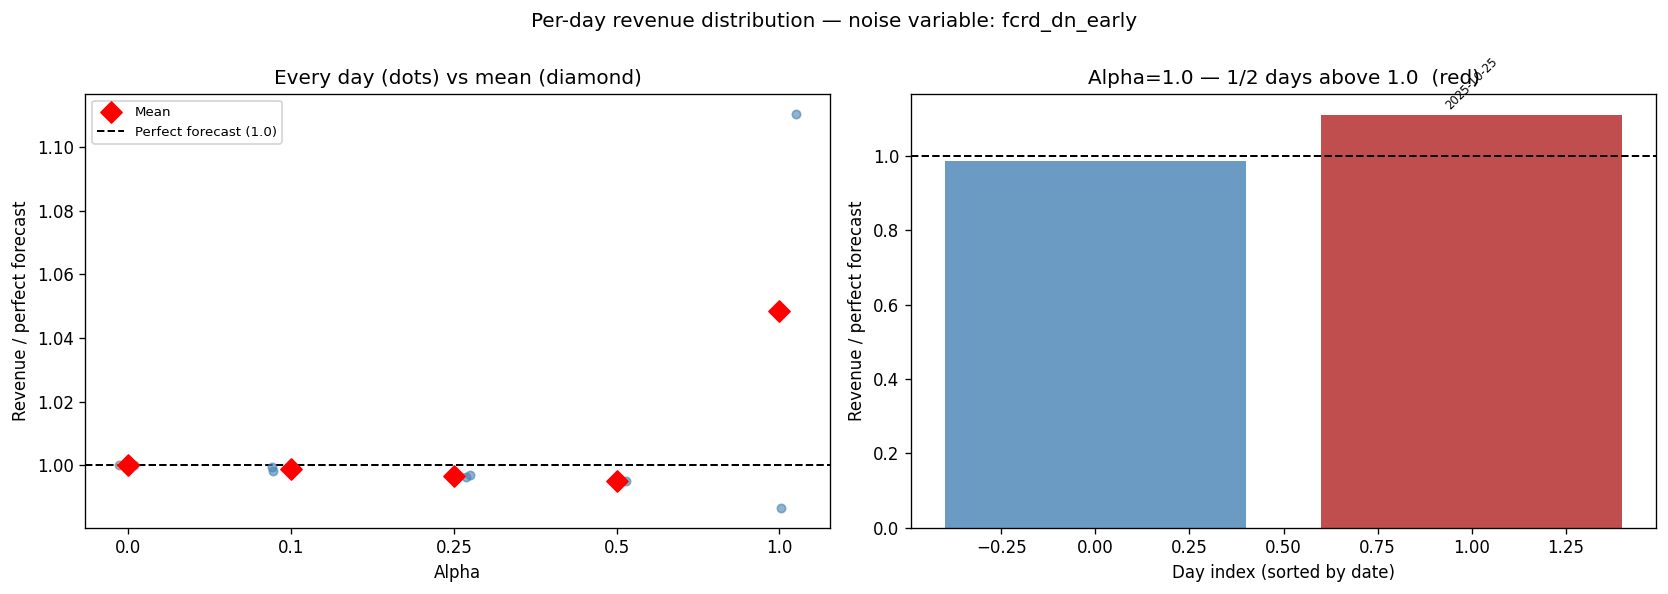


Variable: fcrd_dn_early
   Alpha     N      Mean    Median       Min       Max   % > 1.0
------------------------------------------------------------
    0.00     2     1.000     1.000     1.000     1.000      0.0%
    0.10     2     0.999     0.999     0.998     0.999      0.0%
    0.25     2     0.997     0.997     0.996     0.997      0.0%
    0.50     2     0.995     0.995     0.995     0.995      0.0%
    1.00     2     1.049     1.049     0.987     1.111     50.0%

Days above 1.0 at alpha=1.0:
  2025-10-25  rev_norm=1.1106  total_val=2571.1  nrmse=0.596


In [ ]:
# ── Diagnostic: is the >100% for fcrd_dn_early an outlier day or consistent? ──


VAR = 'fcrd_dn_early'   # ← change to any var key to inspect others

# Collect per-day rev_norm for every (alpha, day)
rows = []
for alpha in ALPHAS:
    for r in daily_data_oaat[VAR][alpha]:
        rows.append({
            'alpha':     alpha,
            'date':      r['date'],
            'rev_norm':  r['rev_norm'],
            'total_val': r['total_value'],
            'nrmse':     np.mean(list(r['nrmse'].values())),
        })
df_diag = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Per-day revenue distribution — noise variable: {VAR}', fontsize=12)

# ── Left: strip plot of all days per alpha, mean overlaid ────────────────
ax = axes[0]
jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(df_diag))
for i, alpha in enumerate(ALPHAS):
    sub = df_diag[df_diag['alpha'] == alpha]['rev_norm'].values
    x = np.full(len(sub), i)
    mask = df_diag['alpha'] == alpha
    ax.scatter(x + jitter[mask.values], sub, s=25, alpha=0.6,
               color='steelblue' if alpha > 0 else 'grey', zorder=3)
    ax.scatter(i, sub.mean(), s=80, marker='D', color='red', zorder=5,
               label='Mean' if i == 0 else '')
ax.axhline(1.0, color='black', lw=1.2, ls='--', label='Perfect forecast (1.0)')
ax.set_xticks(range(len(ALPHAS)))
ax.set_xticklabels([str(a) for a in ALPHAS])
ax.set_xlabel('Alpha')
ax.set_ylabel('Revenue / perfect forecast')
ax.set_title('Every day (dots) vs mean (diamond)')
ax.legend(fontsize=8)

# ── Right: per-day bar chart at highest alpha, sorted by date ─────────────
ax2 = axes[1]
alpha_hi = max(ALPHAS)
sub = df_diag[df_diag['alpha'] == alpha_hi].sort_values('date').reset_index(drop=True)
colors = ['firebrick' if v > 1.0 else 'steelblue' for v in sub['rev_norm']]
ax2.bar(range(len(sub)), sub['rev_norm'], color=colors, alpha=0.8)
ax2.axhline(1.0, color='black', lw=1.2, ls='--')
ax2.set_xlabel('Day index (sorted by date)')
ax2.set_ylabel('Revenue / perfect forecast')
n_above = (sub['rev_norm'] > 1.0).sum()
ax2.set_title(f'Alpha={alpha_hi} — {n_above}/{len(sub)} days above 1.0  (red)')

# Annotate top 3 outliers above 1
top3 = sub[sub['rev_norm'] > 1.0].nlargest(3, 'rev_norm')
for _, row in top3.iterrows():
    ax2.annotate(str(row['date']), xy=(row.name, row['rev_norm']),
                 xytext=(row.name, row['rev_norm'] + 0.015),
                 fontsize=7, ha='center', rotation=45)

plt.tight_layout()
plt.show()

# ── Numerical summary ─────────────────────────────────────────────────────
print(f'\nVariable: {VAR}')
print(f'{"Alpha":>8}  {"N":>4}  {"Mean":>8}  {"Median":>8}  '
      f'{"Min":>8}  {"Max":>8}  {"% > 1.0":>8}')
print('-' * 60)
for alpha in ALPHAS:
    sub = df_diag[df_diag['alpha'] == alpha]['rev_norm']
    if len(sub) == 0: continue
    pct_above = (sub > 1.0).mean() * 100
    print(f'{alpha:>8.2f}  {len(sub):>4}  {sub.mean():>8.3f}  {sub.median():>8.3f}  '
          f'{sub.min():>8.3f}  {sub.max():>8.3f}  {pct_above:>7.1f}%')

# ── List every day above 1.0 at highest alpha ────────────────────────────
print(f'\nDays above 1.0 at alpha={alpha_hi}:')
above = (df_diag[(df_diag['alpha'] == alpha_hi) & (df_diag['rev_norm'] > 1.0)]
         .sort_values('rev_norm', ascending=False))
if len(above) == 0:
    print('  None')
else:
    for _, row in above.iterrows():
        print(f"  {row['date']}  rev_norm={row['rev_norm']:.4f}  "
              f"total_val={row['total_val']:.1f}  nrmse={row['nrmse']:.3f}")

## 12 — Plot

In [ ]:
C_PV='#FFCC00'; C_FCRD_UP_EARLY='#FF7F0E'; C_FCRD_UP_LATE='#D62728'
C_LOAD='#1F77B4'; C_FCRD_DN_EARLY='#00BDF2'; C_FCRD_DN_LATE='#2CA02C'
C_SPOT='#7F7F7F'; C_DAILY='#F42CFF'; C_WEEKLY='#9E00A3'

COLORS = {
    'load': C_LOAD, 'pv': C_PV, 'spot': C_SPOT,
    'fcrd_up_early': C_FCRD_UP_EARLY, 'fcrd_dn_early': C_FCRD_DN_EARLY,
    'fcrd_up_late': C_FCRD_UP_LATE, 'fcrd_dn_late': C_FCRD_DN_LATE,
}

fig, axes = plt.subplots(1, 2, figsize=(21, 7))
fig.patch.set_facecolor('white')
fig.suptitle(
    f'Revenue Sensitivity & Forecast Quality — {len(sampled_dates)}-day average '
    f'(seed={MULTI_SEED})',
    fontsize=14, fontweight='bold', y=0.98
)

# ── Plot 1: Revenue vs α ────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('white')
for var in ALL_VAR_KEYS:
    d = df_avg_oaat[var]
    ax.plot(d['alpha'], d['rev_norm'], marker='o', lw=2, ms=5,
            color=COLORS[var], label=VAR_LABELS[var])
ax.plot(df_avg_all['alpha'], df_avg_all['rev_norm'],
        marker='s', lw=3, ms=8, color='#333333', label='All simultaneous', zorder=10)
ax.axhline(avg_rev_daily,  color=C_DAILY,  ls='--', lw=2, alpha=0.85,
           label=f'Daily persist. D-2 ({avg_rev_daily:.1%})')
ax.axhline(avg_rev_weekly, color=C_WEEKLY, ls='--', lw=2, alpha=0.85,
           label=f'Weekly persist. D-7 ({avg_rev_weekly:.1%})')
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_xlabel('α (fraction of σ̂)', fontsize=11)
ax.set_ylabel('Revenue (fraction of perfect)', fontsize=11)
ax.set_title('Revenue vs α  [multi-day avg]', fontsize=12, fontweight='bold')
ax.legend(fontsize=7, ncol=2)
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)

# ── Plot 2: Revenue vs nRMSE ────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('white')
for var in ALL_VAR_KEYS:
    d = df_avg_oaat[var]
    ax.plot(d['nrmse'], d['rev_norm'], marker='o', lw=2, ms=5,
            color=COLORS[var], label=VAR_LABELS[var])
avg_nrmses_all = [np.mean(list(r['nrmse'].values())) for r in avg_results_all]
ax.plot(avg_nrmses_all, df_avg_all['rev_norm'],
        marker='s', lw=3, ms=8, color='#333333', label='All simultaneous', zorder=10)
ax.scatter([avg_nrmse_daily],  [avg_rev_daily],  color=C_DAILY,  s=200, marker='*',
           zorder=15, edgecolors='black', lw=0.8, label='Daily persist.')
ax.scatter([avg_nrmse_weekly], [avg_rev_weekly], color=C_WEEKLY, s=200, marker='*',
           zorder=15, edgecolors='black', lw=0.8, label='Weekly persist.')
ax.annotate(f'D-2\n({avg_rev_daily:.1%})', (avg_nrmse_daily, avg_rev_daily),
            textcoords='offset points', xytext=(8, -12), fontsize=8, color=C_DAILY)
ax.annotate(f'D-7\n({avg_rev_weekly:.1%})', (avg_nrmse_weekly, avg_rev_weekly),
            textcoords='offset points', xytext=(8, -12), fontsize=8, color=C_WEEKLY)
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_xlabel('nRMSE (forecast quality)', fontsize=11)
ax.set_ylabel('Revenue (fraction of perfect)', fontsize=11)
ax.set_title('Revenue vs nRMSE  [multi-day avg]', fontsize=12, fontweight='bold')
ax.legend(fontsize=7, ncol=2)
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
PLOT_PATH = os.path.join(FIGURES_DIR, 'sensitivity_summary.png')
plt.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f'Plot saved: {PLOT_PATH}')

## 13 — Save results to Drive

In [ ]:
# Save individual day results
ind_rows = []
for alpha in ALPHAS:
    for r in daily_data_all[alpha]:
        ind_rows.append({'date':str(r['date']),'sweep':'all','var':'all','alpha':alpha,
                         'rev_norm':r['rev_norm'],'total_value':r['total_value']})
for var in ALL_VAR_KEYS:
    for alpha in ALPHAS:
        for r in daily_data_oaat[var][alpha]:
            ind_rows.append({'date':str(r['date']),'sweep':'oaat','var':var,'alpha':alpha,
                             'rev_norm':r['rev_norm'],'total_value':r['total_value']})
pd.DataFrame(ind_rows).to_csv(f'{OUT_DIR}/individual_day_results.csv', index=False)
print(f'Individual results saved to: {OUT_DIR}/individual_day_results.csv')
print(f'Plot saved to: {PLOT_PATH}')